In [49]:
import pandas as pd

# Define la ruta o el nombre de tu archivo CSV

#periodicos = ['20minutos', 'abc', 'publico', 'larazon', 'vanguardia', 'elpais']
periodicos = ['larazon', '20minutos']
df_list = []

for i in periodicos:
    path = f'data_{i}.csv'
    df_list.append(pd.read_csv(path))

df = pd.concat(df_list, ignore_index=True)

In [50]:
df.head(5)

,periodico,fecha,titulo,texto,url
0,La Razón,2026-02-03 14:26:31,Lanchas armadas intentan interceptar un buque ...,Última hora de la guerra de Irán Un grupo de p...,https://www.larazon.es/internacional/lanchas-a...
1,La Razón,2026-02-04 14:13:29,Un F-35 derribó al dron iraní que se acercaba ...,Última hora de la guerra de Irán Un caza furti...,https://www.larazon.es/internacional/f35-derri...
2,La Razón,2026-02-17 14:06:12,Irán anuncia el cierre del estrecho de Ormuz e...,Última hora de la guerra de Irán Irán cerrará ...,https://www.larazon.es/internacional/iran-anun...
3,La Razón,2026-03-03 09:25:21,El precio del gas se duplica en 48 horas por l...,Última hora de la guerra de Irán El precio del...,https://www.larazon.es/economia/precio-gas-dup...
4,La Razón,2026-03-03 10:03:19,Los mapas de la tormenta perfecta en Ormuz: un...,Última hora de la guerra de Irán Todo el mundo...,https://www.larazon.es/economia/mapas-tormenta...


In [58]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

# 1. Preparación inicial
# Descargamos "stopwords" (palabras vacías como "el", "de", "y" que no aportan significado)
nltk.download('stopwords')
stop_words_es = stopwords.words('spanish')

# ==========================================
# PARTE A: Análisis de Polaridad
# ==========================================

# Función para calcular la polaridad (de -1.0 a 1.0)
def calcular_polaridad(texto):
    # Nota: TextBlob funciona nativamente en inglés. 
    # Usamos una traducción interna rápida al inglés para evaluar textos en español.
    try:
        analisis = TextBlob(texto).translate(from_lang='es', to='en')
        return analisis.sentiment.polarity
    except:
        # En caso de error de conexión con el traductor, usamos el original
        return TextBlob(texto).sentiment.polarity

# Aplicamos la función y creamos una nueva columna
df['polaridad'] = df['texto'].apply(calcular_polaridad)

# Etiquetamos el resultado para hacerlo más legible
df['sentimiento'] = df['polaridad'].apply(
    lambda p: 'Positivo' if p > 0.1 else ('Negativo' if p < -0.1 else 'Neutral')
)

# ==========================================
# PARTE B: Topic Modeling (LDA)
# ==========================================

# 1. Convertimos el texto a una matriz matemática contando las palabras
vectorizador = CountVectorizer(stop_words=stop_words_es, max_df=0.9, min_df=1)
matriz_palabras = vectorizador.fit_transform(df['texto'])

# 2. Entrenamos el modelo LDA. Aquí le pedimos que busque 2 temas principales.
numero_temas = 3
lda = LatentDirichletAllocation(n_components=numero_temas, random_state=42)
lda.fit(matriz_palabras)

# 3. Asignamos el tema dominante a cada noticia original
temas_asignados = lda.transform(matriz_palabras)
df['id_tema'] = temas_asignados.argmax(axis=1)

# ==========================================
# PARTE C: Visualizar Resultados
# ==========================================

print("--- DATAFRAME FINAL ---")
print(df[['texto', 'sentimiento', 'id_tema']])
print("\n--- QUÉ SIGNIFICA CADA TEMA ---")

# Función para ver las palabras más repetidas de cada tema creado
palabras = vectorizador.get_feature_names_out()
for idx, tema in enumerate(lda.components_):
    palabras_clave = [palabras[i] for i in tema.argsort()[:-3 - 1:-1]]
    print(f"Tema {idx}: {', '.join(palabras_clave)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joanm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- DATAFRAME FINAL ---
                                                 texto sentimiento  id_tema
0    Última hora de la guerra de Irán Un grupo de p...     Neutral        0
1    Última hora de la guerra de Irán Un caza furti...     Neutral        0
2    Última hora de la guerra de Irán Irán cerrará ...     Neutral        0
3    Última hora de la guerra de Irán El precio del...     Neutral        0
4    Última hora de la guerra de Irán Todo el mundo...     Neutral        0
..                                                 ...         ...      ...
137  El Gobierno aprueba el Plan de Vivienda con 7....     Neutral        0
138  El Gobierno aprueba el Plan de Vivienda con 7....     Neutral        1
139  El Gobierno aprueba el Plan de Vivienda con 7....     Neutral        1
140  El Gobierno aprueba el Plan de Vivienda con 7....     Neutral        1
141  El Gobierno aprueba el Plan de Vivienda con 7....     Neutral        0

[142 rows x 3 columns]

--- QUÉ SIGNIFICA CADA TEMA ---
Tema 0:

In [52]:
df.head(5)

,periodico,fecha,titulo,texto,url,polaridad,sentimiento,id_tema
0,La Razón,2026-02-03 14:26:31,Lanchas armadas intentan interceptar un buque ...,Última hora de la guerra de Irán Un grupo de p...,https://www.larazon.es/internacional/lanchas-a...,0.000000,Neutral,0
1,La Razón,2026-02-04 14:13:29,Un F-35 derribó al dron iraní que se acercaba ...,Última hora de la guerra de Irán Un caza furti...,https://www.larazon.es/internacional/f35-derri...,0.000000,Neutral,0
2,La Razón,2026-02-17 14:06:12,Irán anuncia el cierre del estrecho de Ormuz e...,Última hora de la guerra de Irán Irán cerrará ...,https://www.larazon.es/internacional/iran-anun...,0.000000,Neutral,0
3,La Razón,2026-03-03 09:25:21,El precio del gas se duplica en 48 horas por l...,Última hora de la guerra de Irán El precio del...,https://www.larazon.es/economia/precio-gas-dup...,0.066667,Neutral,2
4,La Razón,2026-03-03 10:03:19,Los mapas de la tormenta perfecta en Ormuz: un...,Última hora de la guerra de Irán Todo el mundo...,https://www.larazon.es/economia/mapas-tormenta...,0.066667,Neutral,0


In [53]:
df_pol = pd.DataFrame()

list_dic = []

periodicos = df['periodico'].unique()

for i in periodicos:
    
    df_sub = df[df['periodico'] == i]

    dic = {
        'Periodico': i,
        'Positivo': len(df_sub[df_sub['sentimiento'] == 'Positivo']),
        'Negativo': len(df_sub[df_sub['sentimiento'] == 'Negativo']),
        'Neutral': len(df_sub[df_sub['sentimiento'] == 'Neutral'])
    }
    list_dic.append(dic)

df_pol = pd.DataFrame(list_dic)
print(df_pol)

   Periodico  Positivo  Negativo  Neutral
0   La Razón         9         9       67
1  20minutos        10         7       40


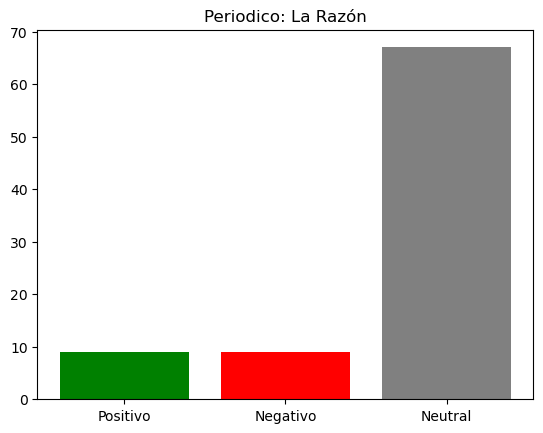

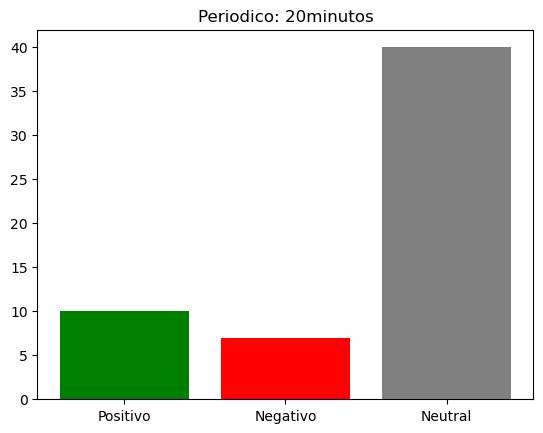

In [56]:
import matplotlib.pyplot as plt

for i in periodicos:
    
    nombre_periodico = i

    # Los datos tal cual los tienes en tu imagen
    datos_sentimiento = {
        'Positivo': df_pol[df_pol['Periodico'] == nombre_periodico]['Positivo'].values[0],
        'Negativo': df_pol[df_pol['Periodico'] == nombre_periodico]['Negativo'].values[0],
        'Neutral': df_pol[df_pol['Periodico'] == nombre_periodico]['Neutral'].values[0]
    }

    plt.bar(datos_sentimiento.keys(), datos_sentimiento.values(), color=['green', 'red', 'gray'])
    plt.title(f'Periodico: {nombre_periodico}')
    plt.show()